---

---

⚠️ **Warning:**  This script was created for testing and quick calculations and not for the purpose of creating clean and efficient code. Optimisation of this script is planned for the future.

---
---

In [ ]:
from itertools import combinations
from math import ceil
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
from scipy import stats
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy, wasserstein_distance
from sklearn.metrics import roc_auc_score, roc_curve

In [ ]:


# 1. lt1
qubitsR_lt1 = np.load('./npz/np_qubitsReal_lt1.npz', allow_pickle=True)
qutritsR_lt1 = np.load('./npz/np_qutritsReal_lt1.npz', allow_pickle=True)
qubitsS_lt1 = np.load('./npz/np_qubitsSimulado_lt1.npz', allow_pickle=True)
qutritsd0dz_lt1 = np.load('./npz/np_qutrits_d0dz.npz', allow_pickle=True)
qutrits_tau12E_lt1 = np.load('./npz/np_qutrits_tau12E.npz', allow_pickle=True)
qutrits_tau23E_lt1 = np.load('./npz/np_qutrits_tau23E.npz', allow_pickle=True)
qutrits_tau34E_lt1 = np.load('./npz/np_qutrits_tau34E.npz', allow_pickle=True)
qubitsR_back = np.load('./npz/np_qubitsReal_back.npz', allow_pickle=True)
qutritsR_back = np.load('./npz/np_qutritsReal_back.npz', allow_pickle=True)
qubitsS_back = np.load('./npz/np_qubitsSimulado_back.npz', allow_pickle=True)
qutritsd0dz_back = np.load('./npz/np_qutrits_d0dz_back.npz', allow_pickle=True)
qutrits_tau12E_back = np.load('./npz/np_qutrits_tau12E_back.npz', allow_pickle=True)
qutrits_tau23E_back = np.load('./npz/np_qutrits_tau23E_back.npz', allow_pickle=True)
qutrits_tau34E_back = np.load('./npz/np_qutrits_tau34E_back.npz', allow_pickle=True)
qutrits_3_rand = np.load('./npz/np_qutrits_tau23E_3_rand.npz', allow_pickle=True)
qutrits_3_max = np.load('./npz/np_qutrits_tau23E_3_max.npz', allow_pickle=True)
qutrits_3_minus = np.load('./npz/np_qutrits_tau23E_3_minus.npz', allow_pickle=True)
qubitsR_lt2 = np.load('./npz/np_qubitsReal_lt2.npz', allow_pickle=True)
qutritsR_lt2 = np.load('./npz/np_qutritsReal_lt2.npz', allow_pickle=True)
qubitsS_lt2 = np.load('./npz/np_qubitsSimulado_lt2.npz', allow_pickle=True)
qutritsd0dz_lt2 = np.load('./npz/np_qutrits_d0dz_lt2.npz', allow_pickle=True)
qutrits_tau12E_lt2 = np.load('./npz/np_qutrits_tau12E_lt2.npz', allow_pickle=True)
qutrits_tau23E_lt2 = np.load('./npz/np_qutrits_tau23E_lt2.npz', allow_pickle=True)
qutrits_tau34E_lt2 = np.load('./npz/np_qutrits_tau34E_lt2.npz', allow_pickle=True)
qubits10 = np.load('./npz/np_qubitsSimulado_10_lt2.npz', allow_pickle=True)
qutritsR_0 = np.load('./npz/np_qutritsReal_0.npz', allow_pickle=True)
ceros_data = {key: np.zeros_like(qutritsR_0[key]) for key in qutritsR_0.files}

np.savez('./npz/np_qutritsReal_0_zeros.npz', **ceros_data)
np.savez('./npz/np_qubits_10_zeros.npz', **ceros_data)

qubits10_zeros = np.load('./npz/np_qubits_10_zeros.npz', allow_pickle=True)
qutritsR_0_zeros = np.load('./npz/np_qutritsReal_0_zeros.npz', allow_pickle=True)

### **General functions**

In [ ]:
def compute_wasserstein_runs2(signal_runs, background_runs):
    Ws = []

    for s in signal_runs:
        for b in background_runs:
            w = wasserstein_distance(s, b)
            Ws.append(w)

    return np.mean(Ws), np.std(Ws), np.array(Ws)

def compute_wasserstein_runs(signal_runs, background_runs):
    Ws = [wasserstein_distance(s, b) for s, b in zip(signal_runs, background_runs)]
    
    return np.mean(Ws), np.std(Ws), np.array(Ws)

def compute_tpr_vs_fpr(
    fpr_list,
    tpr_list,
    signal_label=r"$\text{Signal}$",
    dataset_label=r"$\text{Dataset}$", 
    target_fprs=None,
    make_plot=False
):
    if target_fprs is None:
        target_fprs = np.logspace(-4, 0, 50)

    results = {}
    for target in target_fprs:
        tpr_vals = [
            np.interp(target, fpr, tpr)
            for fpr, tpr in zip(fpr_list, tpr_list)
        ]
        results[target] = (
            np.mean(tpr_vals),
            np.std(tpr_vals)
        )

    print(f"\n=== TPR vs FPR para {signal_label} ===")
    puntos_clave = [0.1, 0.01, 0.001]
    for target in puntos_clave:
        if target in results:
            m, s = results[target]
            print(f"FPR = {target:.7f} -> TPR = {m:.7f} ± {s}")

    if make_plot:
        fprs = np.array(list(results.keys()))
        means = np.array([v[0] for v in results.values()])
        stds  = np.array([v[1] for v in results.values()])

        plt.figure(figsize=(7, 5))

        # Usamos la etiqueta LaTeX en el label del plot
        plt.plot(fprs, means, label=f"Mean TPR ({signal_label})", color='blue', lw=2)
        plt.fill_between(fprs, means - stds, means + stds, color='blue', alpha=0.2, label=r"$1\sigma$ band")

        plt.xscale("log")
        plt.xlabel("False Positive Rate (Background Acceptance)")
        plt.ylabel("True Positive Rate (Signal Efficiency)")
        plt.title(f"{signal_label} performance in {dataset_label}")
        plt.grid(True, which="both", ls="-", color='whitesmoke', alpha=0.5)
        plt.legend(loc="upper left")
        plt.show()

    return results


def get_tpr_stats(fpr_list, tpr_list, target_fprs=None):
    if target_fprs is None:
        target_fprs = np.logspace(-4, 0, 50)

    results = {}
    for target in target_fprs:
        tpr_vals = [np.interp(target, fpr, tpr) for fpr, tpr in zip(fpr_list, tpr_list)]
        results[target] = (np.mean(tpr_vals), np.std(tpr_vals))
    return results

def add_performance_curve(ax, fpr_list, tpr_list, label, color, target_fprs=None):
    stats = get_tpr_stats(fpr_list, tpr_list, target_fprs)
    
    fprs = np.array(list(stats.keys()))
    means = np.array([v[0] for v in stats.values()])
    stds  = np.array([v[1] for v in stats.values()])

    ax.plot(fprs, means, label=label, color=color, lw=0.8, zorder=3)
    ax.fill_between(fprs, 
                    np.maximum(0, means - stds), 
                    np.minimum(1, means + stds), 
                    color=color, alpha=0.3, zorder=2, label=f"$1\sigma$ uncertainty")

In [ ]:
def process_model(data, n_runs):

    back_data  = data['fil_100_back_S'].squeeze()
    HToBB_data = data['fil_100_HToBB_S'].squeeze()
    WToQQ_data = data['fil_100_WToQQ_S'].squeeze()
    TTBar_data = data['fil_100_TTBar_S'].squeeze()

    results = {
        "HToBB": {"fpr": [], "tpr": []},
        "WToQQ": {"fpr": [], "tpr": []},
        "TTBar": {"fpr": [], "tpr": []}
    }

    for i in range(n_runs):

        background = 1 - np.asarray(back_data[i])
        signals = {
            "HToBB": 1 - np.asarray(HToBB_data[i]),
            "WToQQ": 1 - np.asarray(WToQQ_data[i]),
            "TTBar": 1 - np.asarray(TTBar_data[i])
        }

        for signal_name, signal_scores in signals.items():

            y_true = np.concatenate([
                np.zeros_like(background),
                np.ones_like(signal_scores)
            ])

            scores = np.concatenate([
                background,
                signal_scores
            ])

            fpr, tpr, _ = roc_curve(y_true, scores)

            results[signal_name]["fpr"].append(fpr)
            results[signal_name]["tpr"].append(tpr)

    return results

In [ ]:
roc_results = {}
roc_results["Qubits10"] = process_model(qubits10, 10)
roc_results["QubitsReal"] = process_model(qubitsR_lt1, 100)
roc_results["QutritsReal"] = process_model(qutritsR_lt1, 100)
roc_results["QutritsR_0"] = process_model(qutritsR_0, 100)
roc_results["QubitsS"] = process_model(qubitsS_lt1, 100)
roc_results["Tau12E"] = process_model(qutrits_tau12E_lt1, 100)
roc_results["Tau23E"] = process_model(qutrits_tau23E_lt1, 100)
roc_results["Tau34E"] = process_model(qutrits_tau34E_lt1, 100)
roc_results["d0dz"] = process_model(qutritsd0dz_lt1, 100)

In [ ]:
import matplotlib.gridspec as gridspec

def plot_signal_comparison(roc_results):

    signal_names = {
        "HToBB": r"$H \to b\bar{b}$",
        "WToQQ": r"$W \to q\bar{q}$",
        "TTBar": r"$t \to bq\bar{q}$"
    }

    signals = list(signal_names.keys())
    n_signals = len(signals)
    model_labels = {
        "Qubits10": r"$\text{Qubits}_{(10)}$",
        "QubitsReal": r"$\text{Qubits}_{(\text{Real})}$",
        "QutritsReal": r"$\text{Qutrits}_{(\text{Real})}$",
        "QutritsR_0": r"$\text{Qutrits}_{(\text{Real},0)}$",
        "QubitsS": r"$\text{Qubits}_{(\text{Simu})}$",
        "Tau12E": r"$\tau_{12},\varepsilon$",
        "Tau23E": r"$\tau_{23},\varepsilon$",
        "Tau34E": r"$\tau_{34},\varepsilon$",
        "d0dz": r"$\varrho_0,\varrho_z$"
        
    }

    colors = plt.cm.tab10.colors
    letters = "abcdefghijklmnopqrstuvwxyz"

    fig = plt.figure(figsize=(18, 6))
    gs = gridspec.GridSpec(
        1, 3,
        figure=fig,
        wspace=0.25 
    )

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])

    axes = [ax1, ax2, ax3]

    for s_idx, signal in enumerate(signals):
        ax = axes[s_idx]

        for m_idx, (model_name, model_data) in enumerate(roc_results.items()):

            fpr_list = model_data[signal]["fpr"]
            tpr_list = model_data[signal]["tpr"]

            mean_tpr, std_tpr, auc = mean_roc(
                fpr_list,
                tpr_list
            )

            color = colors[m_idx % len(colors)]
            label = rf"{model_labels[model_name]} (AUC={auc:.3f})"

            ax.plot(
                COMMON_FPR,
                mean_tpr,
                lw=1.5, 
                color=color,
                label=label
            )

            ax.fill_between(
                COMMON_FPR,
                np.maximum(mean_tpr - std_tpr, 0),
                np.minimum(mean_tpr + std_tpr, 1),
                color=color,
                alpha=0.15
            )

        ax.plot(
            [0, 1],
            [0, 1],
            "--",
            color="gray",
            lw=1
        )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)

        ax.grid(
            True,
            linestyle="-",
            color="whitesmoke",
            alpha=0.8
        )

        ax.set_xlabel(
            "False Positive Rate",
            fontsize=13
        )

        ax.set_ylabel(
            "True Positive Rate",
            fontsize=13
        )

        ax.set_title(
            f"({letters[s_idx]}) {signal_names[signal]}",
            fontsize=15,
            fontweight="bold"
        )

        ax.legend(
            fontsize=10,
            loc="lower right",
            frameon=True
        )

    plt.suptitle(
        "ROC Curves Comparison",
        fontsize=20,
        fontweight="bold",
        y=1.02
    )
    plt.savefig(
        "ROC_signal_comparison.pdf",
        bbox_inches="tight"
    )

    plt.show()

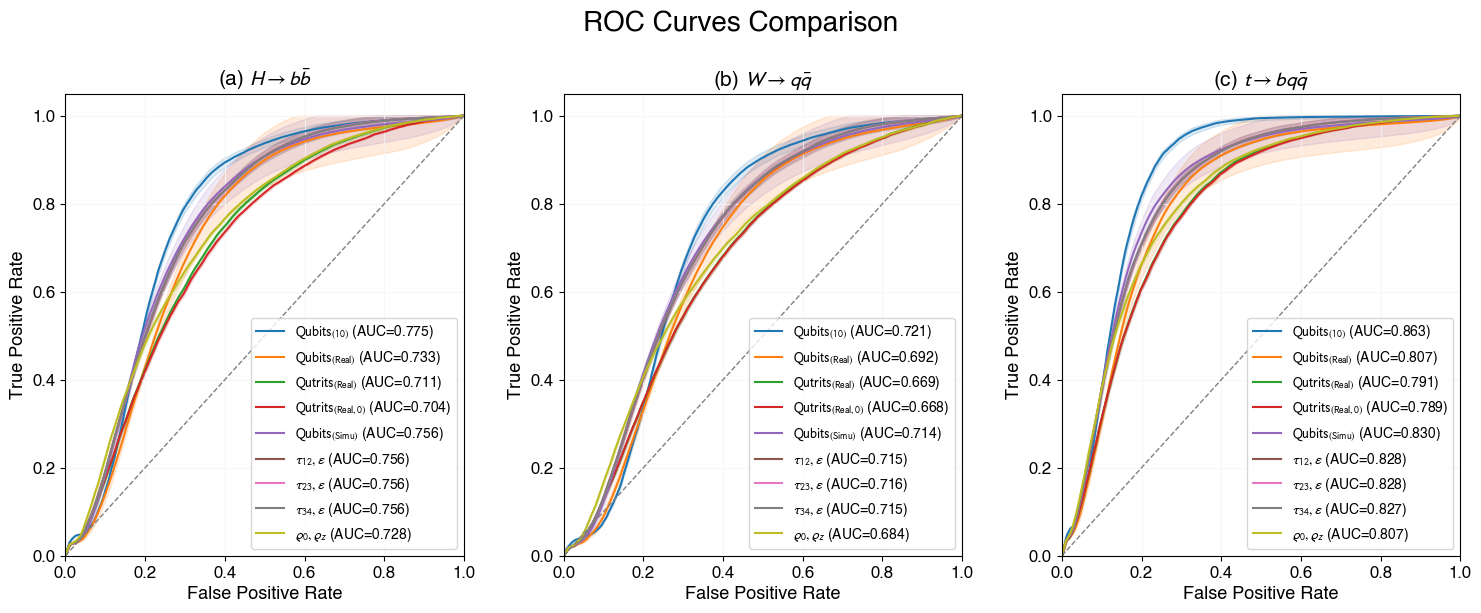

In [ ]:
plot_signal_comparison(roc_results)

In [ ]:


metric_results = {}

def process_model_metrics(data, n_runs):

    back = data['fil_100_back_S'].squeeze()
    hbb  = data['fil_100_HToBB_S'].squeeze()
    wqq  = data['fil_100_WToQQ_S'].squeeze()
    tt   = data['fil_100_TTBar_S'].squeeze()

    samples = {
        "Background": back,
        "HToBB": hbb,
        "WToQQ": wqq,
        "TTBar": tt
    }

    comparisons = [

        ("HToBB", "Background"),
        ("WToQQ", "Background"),
        ("TTBar", "Background"),

        ("HToBB", "WToQQ"),
        ("HToBB", "TTBar"),
        ("WToQQ", "TTBar")
    ]

    results = {}

    for a, b in comparisons:

        results[f"{a}_vs_{b}"] = {
            "wasserstein": [],
            "js": []
        }

    results["Background_vs_Background"] = {
        "wasserstein": [],
        "js": []
    }

    for i in range(n_runs):
        for a, b in comparisons:

            x = np.asarray(samples[a][i], dtype=float)
            y = np.asarray(samples[b][i], dtype=float)

            wd = wasserstein_distance(x, y)

            l = min(len(x), len(y))

            x_js = x[:l].copy()
            y_js = y[:l].copy()

            x_js = np.nan_to_num(x_js, nan=0.0)
            y_js = np.nan_to_num(y_js, nan=0.0)

            x_js += 1e-12
            y_js += 1e-12

            x_js /= x_js.sum()
            y_js /= y_js.sum()

            js = jensenshannon(
                x_js,
                y_js
            )

            results[f"{a}_vs_{b}"]["wasserstein"].append(wd)
            results[f"{a}_vs_{b}"]["js"].append(js)


        bkg = np.asarray(back[i], dtype=float)

        half = len(bkg) // 2

        bkg1 = bkg[:half]
        bkg2 = bkg[half:2*half]
        wd = wasserstein_distance(
            bkg1,
            bkg2
        )
        l = min(len(bkg1), len(bkg2))

        bkg1_js = bkg1[:l].copy()
        bkg2_js = bkg2[:l].copy()

        bkg1_js = np.nan_to_num(
            bkg1_js,
            nan=0.0
        )

        bkg2_js = np.nan_to_num(
            bkg2_js,
            nan=0.0
        )

        bkg1_js += 1e-12
        bkg2_js += 1e-12

        bkg1_js /= bkg1_js.sum()
        bkg2_js /= bkg2_js.sum()

        js = jensenshannon(
            bkg1_js,
            bkg2_js
        )

        results["Background_vs_Background"]["wasserstein"].append(wd)
        results["Background_vs_Background"]["js"].append(js)

    return results



In [108]:
models = {
    "Qubits10": (qubits10, 10),
    "QubitsReal": (qubitsR_lt1, 100),
    "QutritsReal": (qutritsR_lt1, 100),
    "QutritsR_0": (qutritsR_0, 100),
    "QubitsS": (qubitsS_lt1, 100),
    "Tau12E": (qutrits_tau12E_lt1, 100),
    "Tau23E": (qutrits_tau23E_lt1, 100),
    "Tau34E": (qutrits_tau34E_lt1, 100),
    "d0dz": (qutritsd0dz_lt1, 100)
}

metric_results = {
    name: process_model_metrics(data, n_runs)
    for name, (data, n_runs) in models.items()
}

In [ ]:
def plot_metric(metric_results, metric_name):

    comparisons = [

        "HToBB_vs_Background",
        "WToQQ_vs_Background",
        "TTBar_vs_Background",

        "HToBB_vs_WToQQ",
        "HToBB_vs_TTBar",
        "WToQQ_vs_TTBar",

        "Background_vs_Background"
    ]

    comparison_titles = {

        "HToBB_vs_Background":
            r"$H\to b\bar b$ vs Background",

        "WToQQ_vs_Background":
            r"$W\to q\bar q$ vs Background",

        "TTBar_vs_Background":
            r"$t\to bq\bar q$ vs Background",

        "HToBB_vs_WToQQ":
            r"$H\to b\bar b$ vs $W\to q\bar q$",

        "HToBB_vs_TTBar":
            r"$H\to b\bar b$ vs $t\to bq\bar q$",

        "WToQQ_vs_TTBar":
            r"$W\to q\bar q$ vs $t\to bq\bar q$",

        "Background_vs_Background":
            r"Background vs Background"
    }

    model_labels = {
        "Qubits10": r"$\text{Qubits}_{(10)}$",
        "QubitsReal": r"$\text{Qubits}_{(\text{Real})}$",
        "QutritsReal": r"$\text{Qutrits}_{(\text{Real})}$",
        "QutritsR_0": r"$\text{Qutrits}_{(\text{Real},0)}$",
        "QubitsS": r"$\text{Qubits}_{(\text{Simu})}$",
        "Tau12E": r"$\tau_{12},\varepsilon$",
        "Tau23E": r"$\tau_{23},\varepsilon$",
        "Tau34E": r"$\tau_{34},\varepsilon$",
        "d0dz": r"$\varrho_0,\varrho_z$"
        
    }

    colors = plt.cm.tab10.colors

    models = list(metric_results.keys())

    letters = "abcdefghijklmnopqrstuvwxyz"

    n_comparisons = len(comparisons)

    ncols = 3
    nrows = ceil(n_comparisons / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(7*ncols, 5*nrows),
        facecolor="white"
    )

    axes = np.array(axes).flatten()

    for c_idx, comparison in enumerate(comparisons):

        ax = axes[c_idx]

        data = []

        for model in models:

            data.append(
                metric_results[model][comparison][metric_name]
            )

        bp = ax.boxplot(
            data,
            patch_artist=True,
            widths=0.65,
            showfliers=False
        )

        for patch, color in zip(bp["boxes"], colors):

            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        for median in bp["medians"]:
            median.set_linewidth(2.5)
            median.set_color("black")

        for whisker in bp["whiskers"]:
            whisker.set_linewidth(1.5)

        for cap in bp["caps"]:
            cap.set_linewidth(1.5)


        for i, values in enumerate(data):

            x = np.random.normal(
                loc=i + 1,
                scale=0.04,
                size=len(values)
            )

            ax.scatter(
                x,
                values,
                alpha=0.15,
                s=8,
                color="blue",
                zorder=3
            )

        ax.set_xticks(
            np.arange(1, len(models)+1)
        )

        ax.set_xticklabels(
            [
                model_labels.get(m, m)
                for m in models
            ],
            rotation=45,
            ha="right",
            fontsize=16
        )

        ax.set_title(
            f"({letters[c_idx]}) {comparison_titles[comparison]}",
            fontsize=16,
            fontweight="bold"
        )

        ax.grid(
            alpha=0.25,
            axis="y"
        )

        if metric_name == "wasserstein":

            ax.set_ylabel(
                "Wasserstein distance",
                fontsize=14
            )

        elif metric_name == "js":

            ax.set_ylabel(
                "Jensen-Shannon distance",
                fontsize=14
            )

        else:

            ax.set_ylabel(
                metric_name,
                fontsize=14
            )

    for idx in range(
        n_comparisons,
        len(axes)
    ):
        fig.delaxes(
            axes[idx]
        )


    legend_elements = [

        Patch(
            facecolor="lightgray",
            edgecolor="black",
            label="Interquartile range (25%-75%)"
        ),

        Line2D(
            [0],
            [0],
            color="black",
            lw=2.5,
            label="Median"
        ),

        Line2D(
            [0],
            [0],
            marker="|",
            color="black",
            linestyle="None",
            markersize=12,
            label="Whiskers"
        ),

        Line2D(
            [0],
            [0],
            marker="o",
            color="blue",
            linestyle="None",
            markersize=5,
            alpha=0.3,
            label="Individual runs"
        )
    ]

    fig.legend(
        handles=legend_elements,
        loc="upper center",
        ncol=4,
        fontsize=14,
        frameon=True,
        bbox_to_anchor=(0.5, 0.93)
    )


    if metric_name == "wasserstein":
        title = "Wasserstein Distance Comparison"
    elif metric_name == "js":
        title = "Jensen-Shannon Distance Comparison"
    else:

        title = metric_name

    fig.suptitle(
        title,
        fontsize=24,
        fontweight="bold"
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.92]
    )
    plt.savefig(
        f"{metric_name}_boxplots.pdf",
        bbox_inches="tight"
    )
    plt.show()

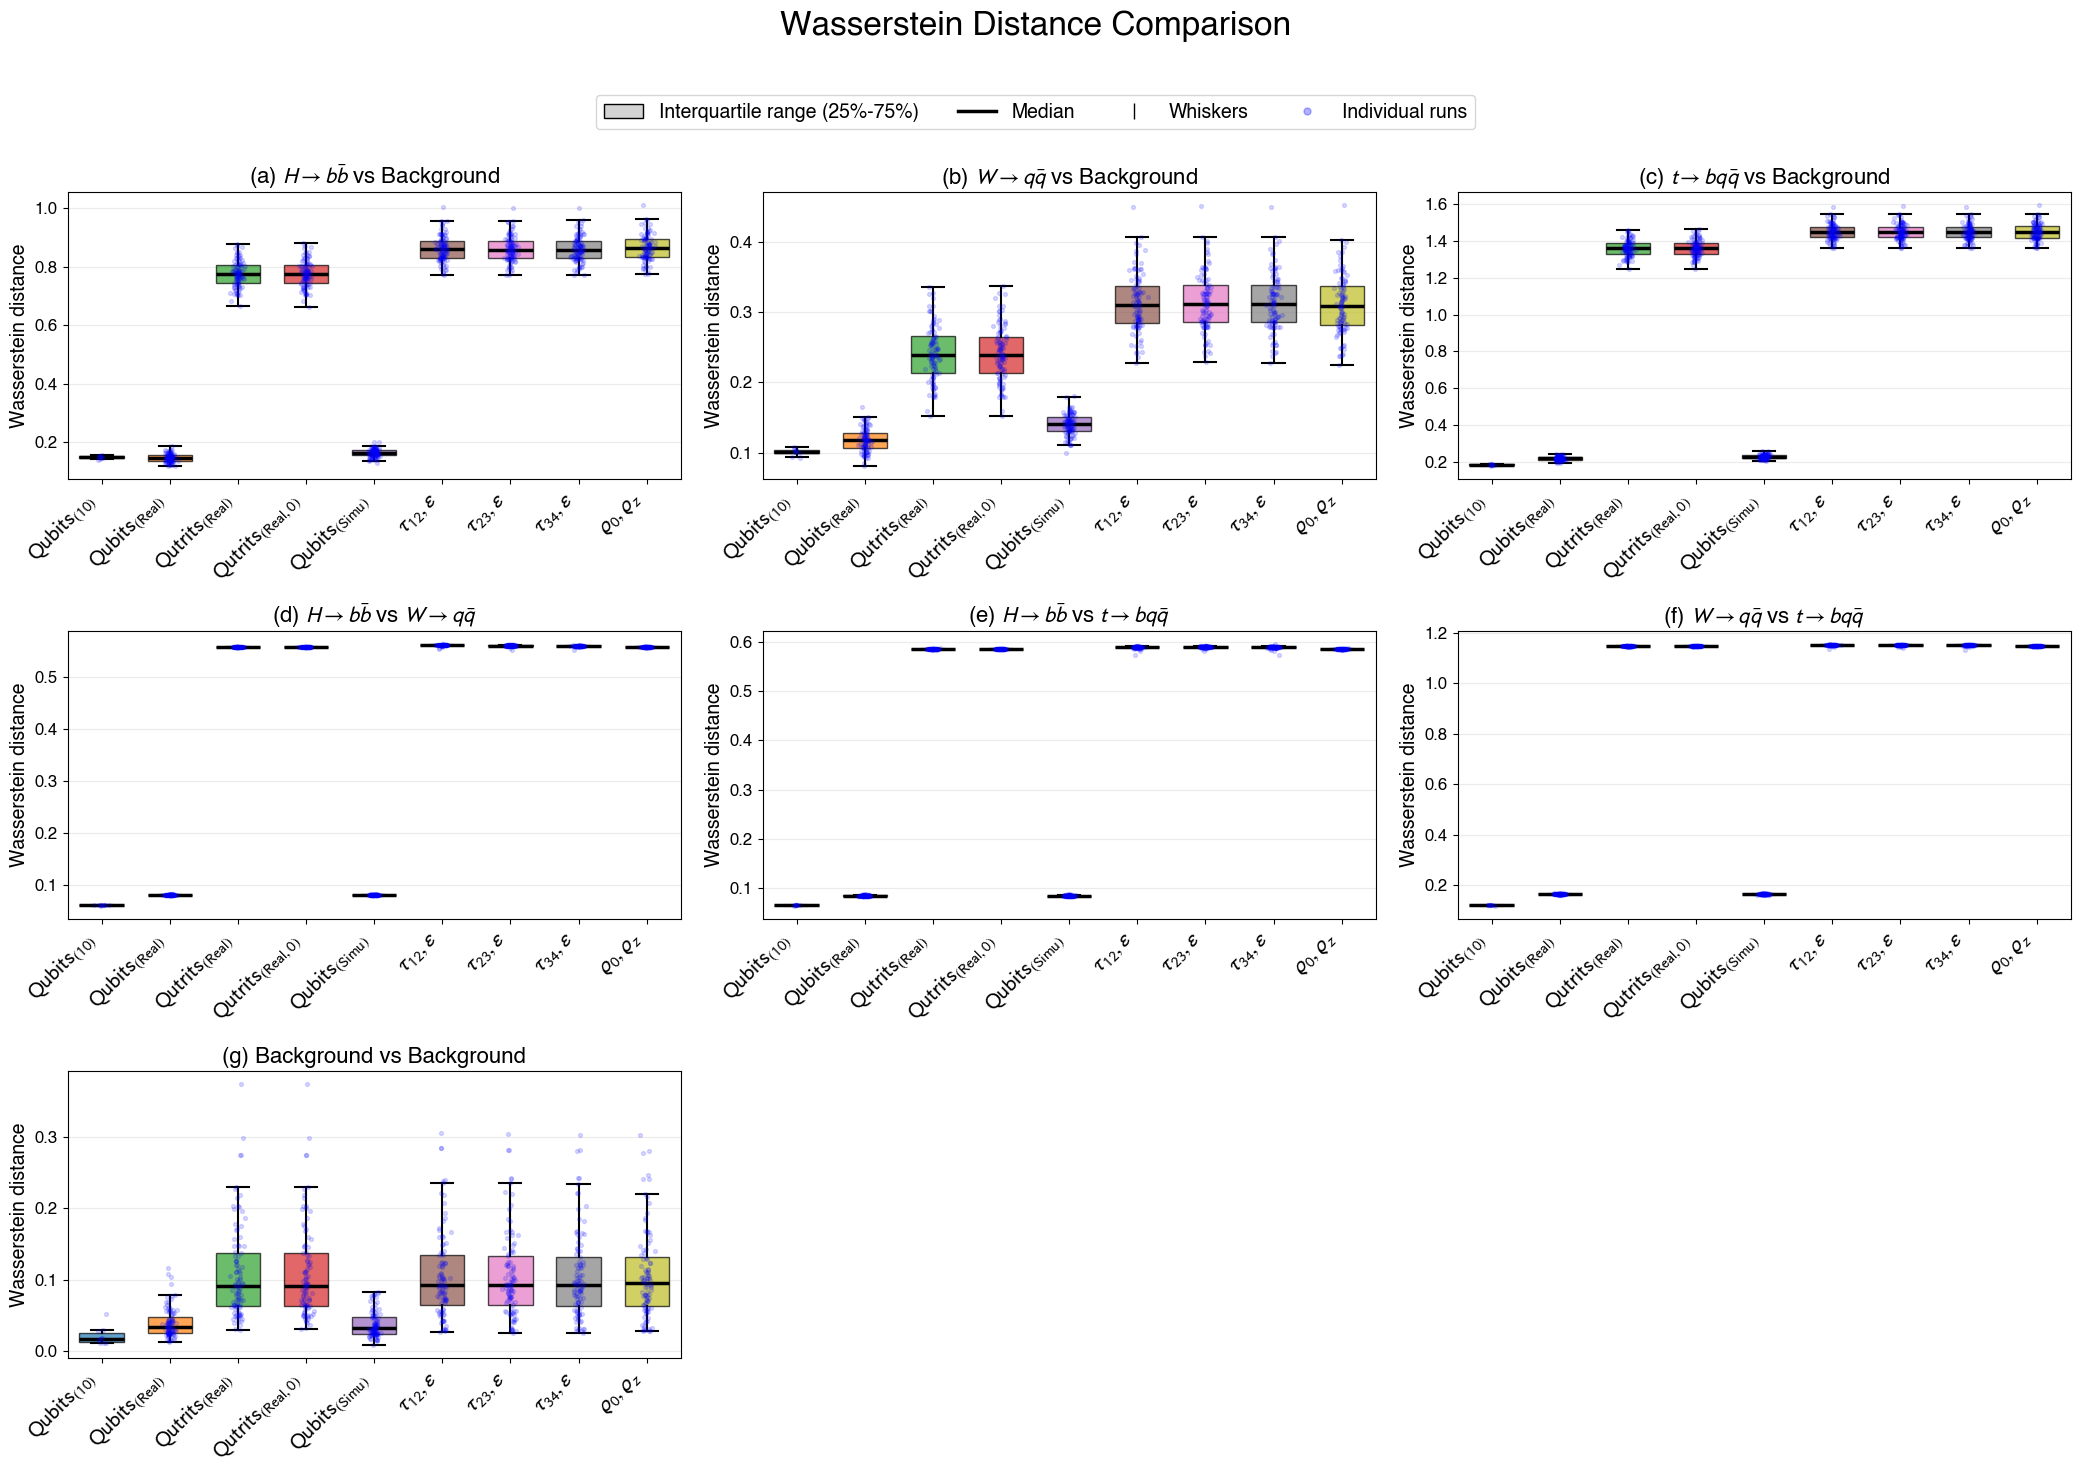

In [114]:
plot_metric(metric_results, "wasserstein")

In [ ]:
for model in metric_results:
    for comparison in metric_results[model]:
        values = metric_results[model][comparison]["js"]
        if len(values) > 0:
            print(
                model,
                comparison,
                np.min(values),
                np.max(values),
                np.mean(values)
            )
            break
    break

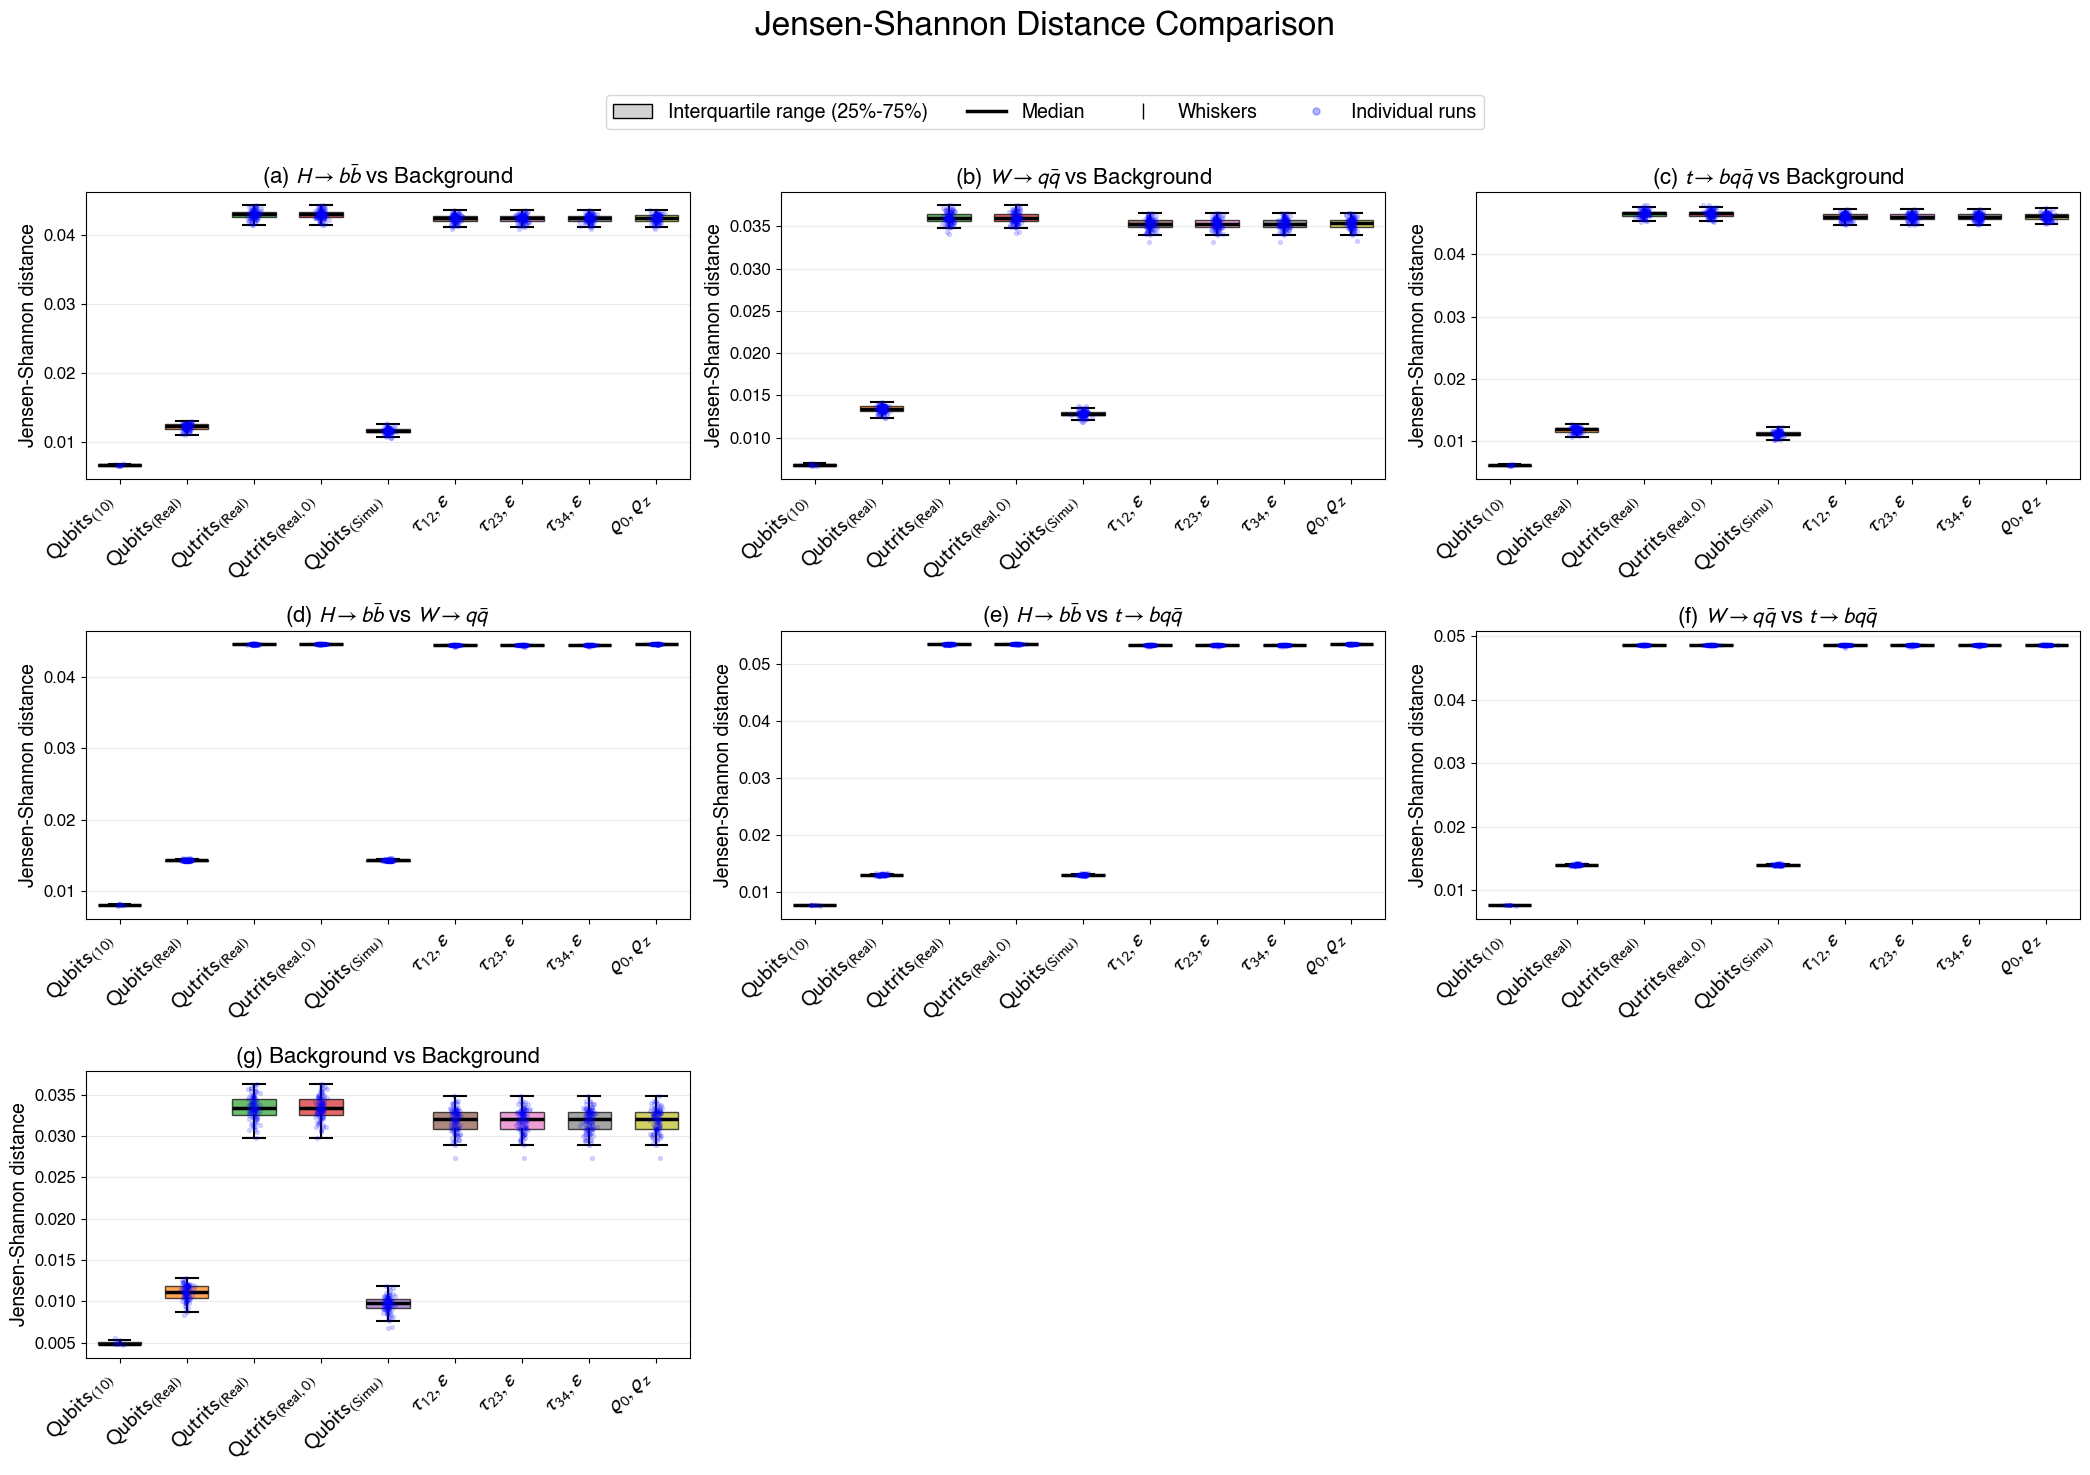

In [115]:
plot_metric(metric_results, "js")

In [ ]:

def compute_auc_runs(data, n_runs):
    """AUC (signal vs background) por ejecución, para HToBB, WToQQ y TTBar."""

    back_data  = data['fil_100_back_S'].squeeze()
    HToBB_data = data['fil_100_HToBB_S'].squeeze()
    WToQQ_data = data['fil_100_WToQQ_S'].squeeze()
    TTBar_data = data['fil_100_TTBar_S'].squeeze()

    aucs = {"HToBB": [], "WToQQ": [], "TTBar": []}

    for i in range(n_runs):
        background = 1 - np.asarray(back_data[i])
        signals = {
            "HToBB": 1 - np.asarray(HToBB_data[i]),
            "WToQQ": 1 - np.asarray(WToQQ_data[i]),
            "TTBar": 1 - np.asarray(TTBar_data[i]),
        }
        for signal_name, signal_scores in signals.items():
            y_true = np.concatenate([
                np.zeros_like(background),
                np.ones_like(signal_scores)
            ])
            scores = np.concatenate([
                background,
                signal_scores
            ])
            aucs[signal_name].append(roc_auc_score(y_true, scores))

    return {k: np.array(v) for k, v in aucs.items()}

latent_models = {
    "Qubits10":    (qubits10_zeros,             qubits10,             10),
    "QubitsReal":  (qubitsR_lt1,          qubitsR_lt2,          100),
    "QutritsReal": (qutritsR_lt1,         qutritsR_lt2,         100),
    "QutritsR_0":   (qutritsR_0_zeros,           qutritsR_0,          100),
    "QubitsS":     (qubitsS_lt1,          qubitsS_lt2,          100),
    "Tau12E":      (qutrits_tau12E_lt1,   qutrits_tau12E_lt2,   100),
    "Tau23E":      (qutrits_tau23E_lt1,   qutrits_tau23E_lt2,   100),
    "Tau34E":      (qutrits_tau34E_lt1,   qutrits_tau34E_lt2,   100),
    "d0dz":        (qutritsd0dz_lt1,      qutritsd0dz_lt2,      100),
}

auc_latent_results = {}

for name, (data_lt1, data_lt2, n_runs) in latent_models.items():
    auc_latent_results[name] = {
        "lt1": compute_auc_runs(data_lt1, n_runs),
        "lt2": compute_auc_runs(data_lt2, n_runs),
    }



qubits10, n_runs =  qubits10, 10
aucs_qubits10_lt2 = compute_auc_runs(qubits10, n_runs)
se_qubits10 = {
    "lt2": {signal: stats.sem(scores) for signal, scores in aucs_qubits10_lt2.items()},
}

for space, signals in se_qubits10.items():
    print(f"--- Qubits10 Standard Error ({space}) ---")
    for signal, se_value in signals.items():
        print(f"{signal}: {se_value:.6f}")

--- Qubits10 Standard Error (lt2) ---
HToBB: 0.002494
WToQQ: 0.002730
TTBar: 0.001411


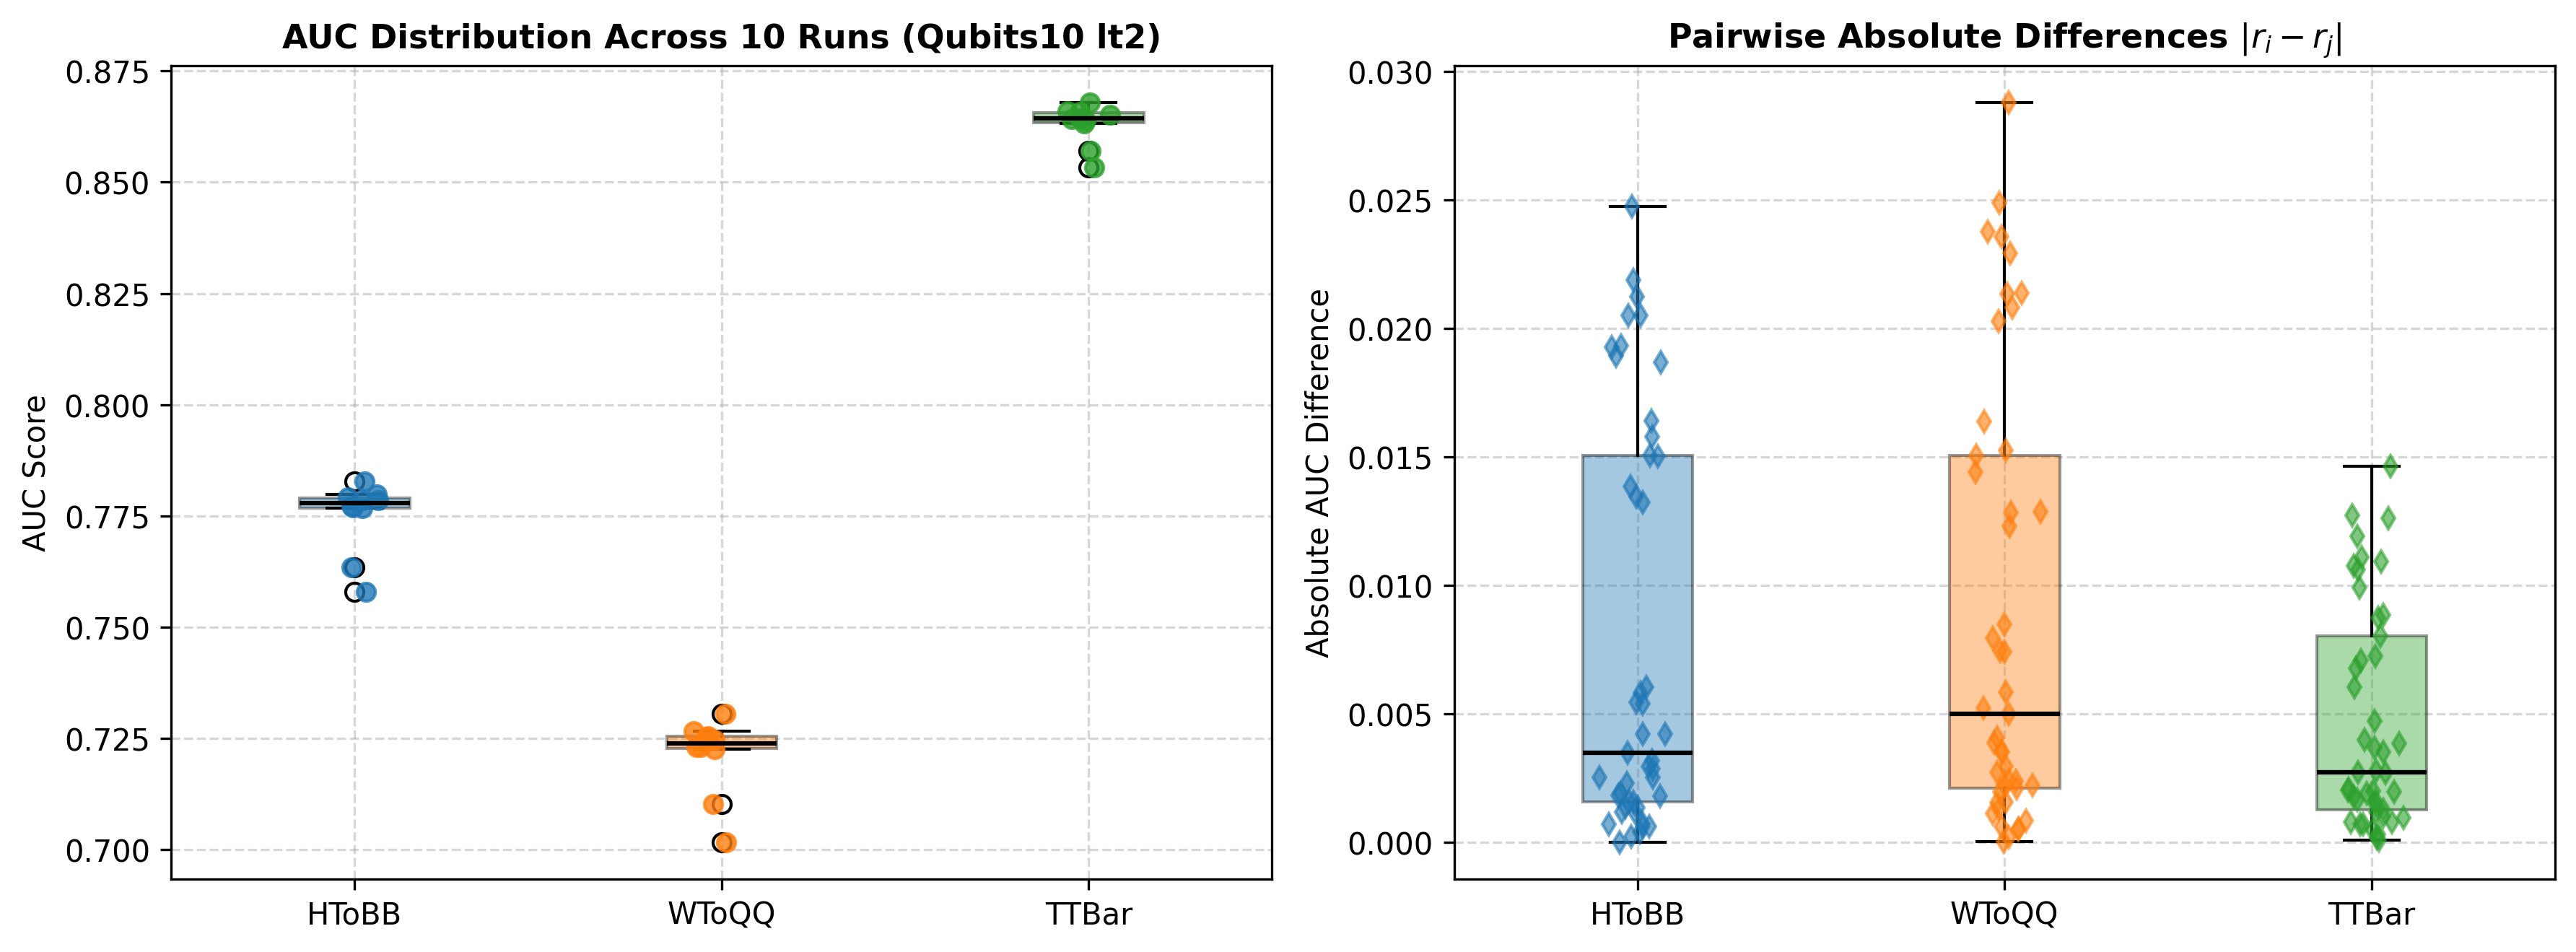

In [ ]:
aucs_qubits10_lt2 = compute_auc_runs(qubits10, 10)
pair_diffs = {}
for signal, auc_list in aucs_qubits10_lt2.items():
    diffs = [abs(r_b - r_a) for r_a, r_b in combinations(auc_list, 2)]
    pair_diffs[signal] = diffs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), dpi=300)
signals = list(aucs_qubits10_lt2.keys())
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

auc_data = [aucs_qubits10_lt2[s] for s in signals]
bp1 = ax1.boxplot(
    auc_data,
    tick_labels=signals,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1.5),
)

for patch, color in zip(bp1["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.4)

np.random.seed(42)  
for i, signal in enumerate(signals, start=1):
    y = aucs_qubits10_lt2[signal]
    x = np.random.normal(i, 0.04, size=len(y))
    ax1.plot(x, y, "o", color=colors[i - 1], alpha=0.8, markersize=6)

ax1.set_title(
    "AUC Distribution Across 10 Runs (Qubits10 lt2)",
    fontsize=11,
    fontweight="bold",
)
ax1.set_ylabel("AUC Score", fontsize=10)
ax1.grid(True, linestyle="--", alpha=0.5)

diff_data = [pair_diffs[s] for s in signals]
bp2 = ax2.boxplot(
    diff_data,
    tick_labels=signals,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1.5),
)

for patch, color in zip(bp2["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.4)

for i, signal in enumerate(signals, start=1):
    y = pair_diffs[signal]
    x = np.random.normal(i, 0.04, size=len(y))
    ax2.plot(x, y, "d", color=colors[i - 1], alpha=0.6, markersize=5)

ax2.set_title(
    "Pairwise Absolute Differences $|r_i - r_j|$",
    fontsize=11,
    fontweight="bold",
)
ax2.set_ylabel("Absolute AUC Difference", fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("qubits10_lt2_auc_spread.pdf", bbox_inches="tight")
plt.show()

In [ ]:
aucs_qubits10_lt2 = compute_auc_runs(qubits10, 10)
pair_diff_ranges = {}

for signal, auc_list in aucs_qubits10_lt2.items():
    abs_diffs = [abs(r_b - r_a) for r_a, r_b in combinations(auc_list, 2)]
    min_diff = np.min(abs_diffs)
    max_diff = np.max(abs_diffs)
    pair_diff_ranges[signal] = (min_diff, max_diff)


print("--- Qubits10 Pairwise Absolute Differences Range (lt2) ---")
for signal, (min_d, max_d) in pair_diff_ranges.items():
    print(
        f"{signal}: min diff = {min_d:.6f}, max diff = {max_d:.6f} -> Rango"
        f" [{min_d:.6f}, {max_d:.6f}]"
    )

--- Qubits10 Pairwise Absolute Differences Range (lt2) ---
HToBB: min diff = 0.000019, max diff = 0.024724 -> Rango [0.000019, 0.024724]
WToQQ: min diff = 0.000028, max diff = 0.028774 -> Rango [0.000028, 0.028774]
TTBar: min diff = 0.000099, max diff = 0.014629 -> Rango [0.000099, 0.014629]


In [ ]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans",
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

_DEFAULT_LATENT_MODEL_LABELS = {
    "Qubits10": r"$\mathrm{Qubits}_{(10)}$",
    "QubitsReal": r"$\mathrm{Qubits}_{(\mathrm{Real})}$",
    "QutritsReal": r"$\mathrm{Qutrits}_{(\mathrm{Real})}$",
    "QutritsR_0": r"$\mathrm{Qutrits}_{(\mathrm{Real},0)}$",
    "QubitsS": r"$\mathrm{Qubits}_{(Simu)}$",
    "Tau12E": r"$\tau_{12},\varepsilon$",
    "Tau23E": r"$\tau_{23},\varepsilon$",
    "Tau34E": r"$\tau_{34},\varepsilon$",
    "d0dz": r"$\varrho_0,\varrho_z$",
    
}
def plot_latent_space_comparison(
    auc_latent_results,
    model_labels=None
):

    if model_labels is None:
        model_labels = _DEFAULT_LATENT_MODEL_LABELS

    signal_names = {
        "HToBB": r"$H\to b\bar b$",
        "WToQQ": r"$W\to q\bar q$",
        "TTBar": r"$t\to bq\bar q$",
    }

    signals = list(signal_names.keys())
    models = list(auc_latent_results.keys())

    letters = "abcdefghijklmnopqrstuvwxyz"

    color_lt1 = "#1f4e79"   
    color_lt2 = "#c0392b"  
    color_line = "#a6a6a6"

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(20, 7),
        facecolor="white",
        sharey=True
    )

    axes = np.array(axes).flatten()

    for s_idx, signal in enumerate(signals):
        ax = axes[s_idx]
        x = np.arange(len(models))
        means_lt1 = []
        stds_lt1 = []
        means_lt2 = []
        stds_lt2 = []

        for model in models:

            aucs_lt1 = np.asarray(
                auc_latent_results[model]["lt1"][signal]
            )
            aucs_lt2 = np.asarray(
                auc_latent_results[model]["lt2"][signal]
            )
            means_lt1.append(
                np.mean(aucs_lt1)
            )
            stds_lt1.append(
                np.std(aucs_lt1)
            )
            means_lt2.append(
                np.mean(aucs_lt2)
            )
            stds_lt2.append(
                np.std(aucs_lt2)
            )

        means_lt1 = np.array(means_lt1)
        stds_lt1 = np.array(stds_lt1)
        means_lt2 = np.array(means_lt2)
        stds_lt2 = np.array(stds_lt2)

        width = 0.18

        for i in range(len(models)):

            ax.plot(
                [x[i] - width, x[i] + width],
                [means_lt1[i], means_lt2[i]],
                color=color_line,
                lw=1.5,
                zorder=1
            )

        ax.errorbar(
            x - width,
            means_lt1,
            yerr=stds_lt1,
            fmt="o",
            ms=8,
            color=color_lt1,
            ecolor=color_lt1,
            elinewidth=1.8,
            capsize=4,
            zorder=3,
            label="Latent space 1"
            if s_idx == 0 else None
        )

        ax.errorbar(
            x + width,
            means_lt2,
            yerr=stds_lt2,
            fmt="s",
            ms=8,
            color=color_lt2,
            ecolor=color_lt2,
            elinewidth=1.8,
            capsize=4,
            zorder=3,
            label="Latent space 2"
            if s_idx == 0 else None
        )

        ax.set_xticks(x)
        ax.set_xticklabels(
            [
                model_labels.get(m, m)
                for m in models
            ],
            rotation=45,
            ha="right",
            fontsize=12
        )

        ax.set_ylim(0.6, 0.9)
        ax.set_ylabel(
            "AUC score",
            fontsize=14
        )
        ax.set_title(
            f"({letters[s_idx]}) {signal_names[signal]}",
            fontsize=17,
            fontweight="bold"
        )
        ax.grid(
            True,
            axis="y",
            ls="-",
            color="whitesmoke",
            alpha=0.9,
            zorder=0
        )

        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.96),
        ncol=2,
        frameon=False,
        fontsize=13
    )

    fig.suptitle(
        r"AUC Scores ($\mu \pm \sigma$)",
        fontsize=24,
        fontweight="bold",
        y=1.02
    )
    plt.tight_layout(
        rect=[0, 0, 1, 0.92]
    )
    plt.savefig(
        "AUC_latent_space_comparison.pdf",
        bbox_inches="tight",
        dpi=300
    )
    plt.show()

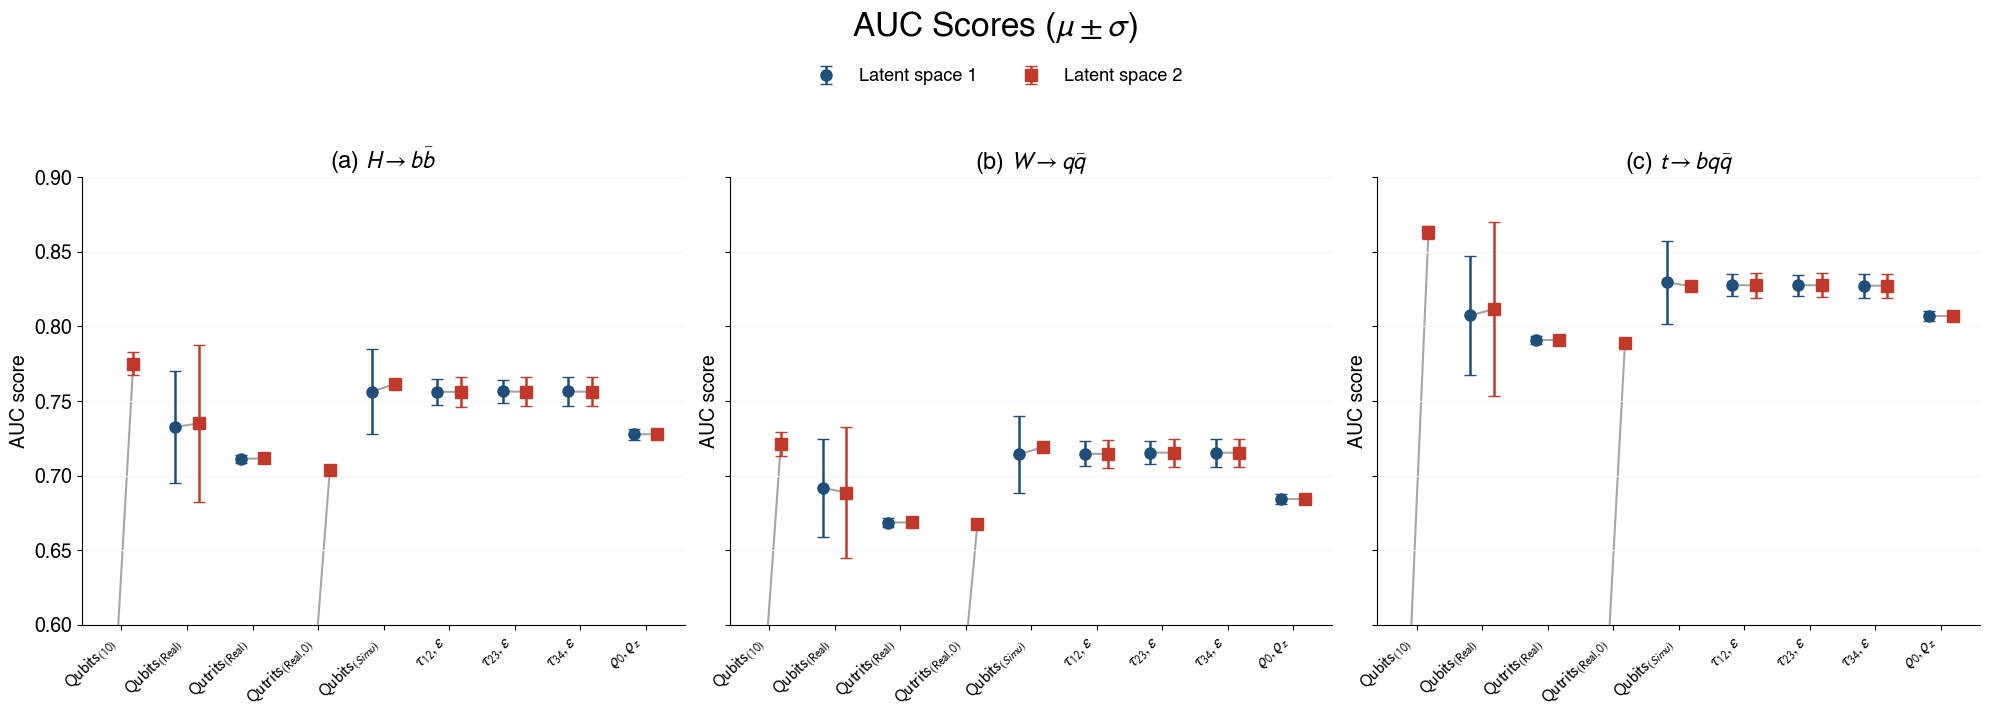

In [12]:
plot_latent_space_comparison(auc_latent_results)

In [ ]:
def plot_physics_histogram(
    data,
    key_back="fil_100_back_S",
    signals_config=None,
    run_idx=34,
    bins_range=(97, 100),
    n_bins=50,
    title=None,
    xlabel=r"Quantum fidelity $\langle \text{T}|\text{R} \rangle$ (in %)",
    ylabel=r"No. of events",
    label_back=r"CMS Data (2016)",
    output_filename="qutritsS_histogram.pdf",
    figsize=(7, 7),
    capsize=0,
    capthick=0.8,
):
    if signals_config is None:
        signals_config = []

    plt.rcParams.update(
        {
            "font.family": "sans-serif",
            "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
            "text.usetex": False,
            "mathtext.fontset": "stixsans",
            "xtick.labelsize": 12,
            "ytick.labelsize": 12,
        }
    )

    fig, ax = plt.subplots(figsize=figsize, facecolor="white")
    bins = np.linspace(bins_range[0], bins_range[1], n_bins)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    data_back = data[key_back].squeeze()[run_idx].flatten()
    ax.hist(
        data_back,
        bins=bins,
        histtype="stepfilled",
        color="#7998CAB6",
        alpha=0.7,
        log=True,
        label=label_back,
    )

    counts_back, _ = np.histogram(data_back, bins=bins)
    mask_back = counts_back > 0
    ax.errorbar(
        bin_centers[mask_back],
        counts_back[mask_back],
        yerr=np.sqrt(counts_back[mask_back]),
        fmt="none",
        ecolor="#333333",
        elinewidth=0.8,
        capsize=capsize,
        capthick=capthick,
    )

    for sig in signals_config:
        sig_data = data[sig["key"]].squeeze()[run_idx].flatten()
        sig_color = sig.get("color", "black")
        sig_label = sig.get("label", "")

        ax.hist(
            sig_data,
            bins=bins,
            histtype="step",
            color=sig_color,
            linewidth=1,
            linestyle="-",
            log=True,
            label=sig_label,
        )

        counts_sig, _ = np.histogram(sig_data, bins=bins)
        mask_sig = counts_sig > 0
        ax.errorbar(
            bin_centers[mask_sig],
            counts_sig[mask_sig],
            yerr=np.sqrt(counts_sig[mask_sig]),
            fmt="none",
            ecolor=sig_color,
            elinewidth=0.8,
            capsize=capsize,
            capthick=capthick,
        )

    handles, labels = ax.get_legend_handles_labels()
    error_handle = ax.errorbar(
        [],
        [],
        yerr=[],
        fmt="none",
        ecolor="black",
        elinewidth=1.2,
        capsize=capsize,
        capthick=1.2,
        label=r"Poisson uncertainty ($\sqrt{N}$)",
    )
    handles.append(error_handle)
    ax.set_yscale("log")
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)

    if title:
        ax.set_title(title, fontsize=20, fontweight="bold", fontname="Helvetica")

    ax.legend(
        handles=handles,
        loc="upper left",
        frameon=True,
        facecolor="white",
        prop={"family": "Helvetica", "size": 15},
    )

    plt.tight_layout()
    plt.savefig(output_filename, bbox_inches="tight")
    plt.show()

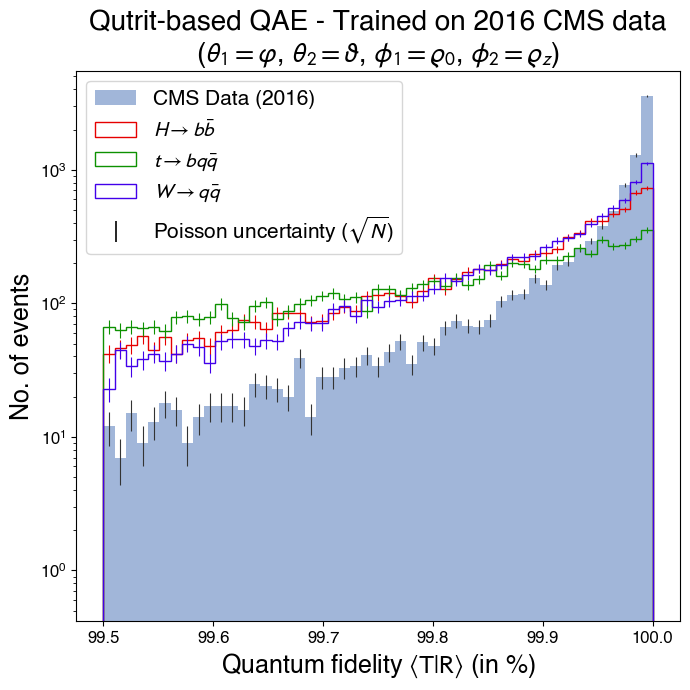

In [ ]:
signals = [
    {
        "key": "fil_100_HToBB_S",
        "label": r"$H \rightarrow b\bar{b}$",
        "color": "#E60000",
    },
    {
        "key": "fil_100_TTBar_S",
        "label": r"$t \rightarrow bq\bar{q}$",
        "color": "#0D9101",
    },
    {
        "key": "fil_100_WToQQ_S",
        "label": r"$W \rightarrow q\bar{q}$",
        "color": "#4200EA",
    },
]

my_title = (
    r"Qutrit-based QAE - Trained on 2016 CMS data"
    "\n"
    r"($\theta_1 = \varphi$, $\theta_2 = \vartheta$, $\phi_1 = \varrho_0$, $\phi_2 = \varrho_z$)"
)

plot_physics_histogram(
    data=qutritsd0dz_lt1,
    key_back="fil_100_back_S",
    signals_config=signals,
    run_idx=34,
    bins_range=(99.5, 100),
    title=my_title,
    output_filename="qutritsR_99.png",
    capsize=0, 
)